# Sanity Check
Sanity check the `map_converter.ipynb`. Sometimes, the centerline generated is not great, such as what you see for `Spielberg_map`. In these cases, you can increase the interpolation interval in `map_converter.ipynb`, and then clean manually.

Then, you can use this book to sanity check again the points.

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from PIL import Image
import os
import pandas as pd

In [57]:
MAP_NAME = 'MoscowRaceway'

In [58]:
if os.path.exists(f"maps/{MAP_NAME}.png"):
    map_img_path = f"maps/{MAP_NAME}.png"
elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
    map_img_path = f"maps/{MAP_NAME}.pgm"
else:
    raise Exception("Map not found!")

map_yaml_path = f"maps/{MAP_NAME}.yaml"
map_img = np.array(Image.open(map_img_path).transpose(Image.FLIP_TOP_BOTTOM))
map_img = map_img.astype(np.float64)

# load map yaml
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        print(ex)

# calculate map parameters
orig_x = origin[0]
orig_y = origin[1]

In [ ]:
track_data = pd.read_csv(f"inputs/tracks/{MAP_NAME}.csv")
scale = 1
x = track_data["# x_m"].to_numpy(dtype=float)
y = track_data["y_m"].to_numpy(dtype=float)
wr = track_data["w_tr_right_m"].to_numpy(dtype=float) * scale
wl = track_data["w_tr_left_m"].to_numpy(dtype=float) * scale

x -= orig_x
y -= orig_y

x /= map_resolution
y /= map_resolution

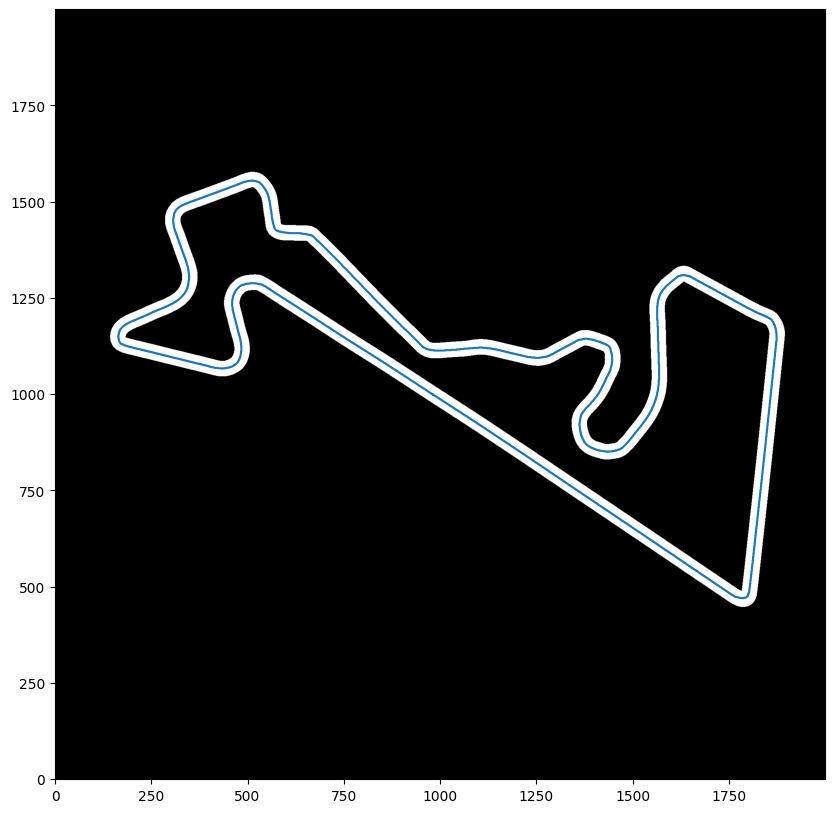

In [60]:
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap="gray", origin="lower")
plt.plot(x,y)

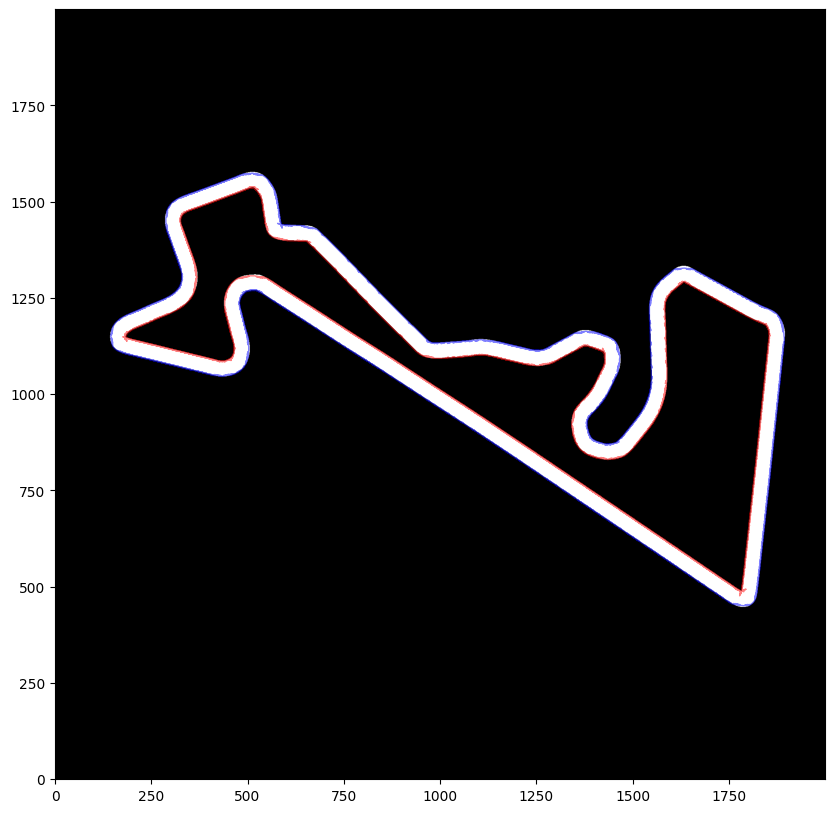

In [ ]:
# Compare track widths

points = np.column_stack((x, y))
n = len(points)
points_closed = np.vstack((points[-1,:], points, points[0,:]))
v = points_closed[2:] - points_closed[:-2]
norms = np.linalg.norm(v, axis=1, keepdims=True)
norms[norms == 0] = 1.0
tangents = v / norms
# Changes from row, col to x, y
normals = np.column_stack((-tangents[:,1], tangents[:, 0]))
left_boundary = points + normals * wl[:, None]
right_boundary = points - normals * wr[:, None]

plt.figure(figsize=(10,10))
# plt.plot(x, y, '--')
plt.plot(left_boundary[:,0], left_boundary[:,1], color='blue', linewidth=1, alpha=0.5)
plt.plot(right_boundary[:,0], right_boundary[:,1], color='red', linewidth=1, alpha=0.5)
plt.imshow(map_img, cmap="gray", origin="lower")
plt.show()